# Quantum Markov music sampler

This notebook is the Stage 2 generator: it keeps the `(interval, duration, silence)` representation, but first compresses complete triplets into **event tokens**. It then learns first-order transition probabilities between tokens:

```text
P(next_token | current_token)
```

For the top current tokens, it builds one Qiskit `StatePreparation` circuit per conditional distribution. A global token circuit is also built and used as fallback for rare/unseen states.

No formal metrics are computed here. The goal is to make the conditional generation loop concrete and easy to refine.


In [1]:
# If this notebook is running in a fresh environment, uncomment these lines first.
# %pip install qiskit qiskit-aer matplotlib numpy pylatexenc

from __future__ import annotations

from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
import os
import wave

os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib-cache").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt

SEED = 2026
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)

MIDI_DIR = Path("midi")
OUTPUT_DIR = Path("outputs_markov")
OUTPUT_DIR.mkdir(exist_ok=True)

# Data selection. If USER_MIDI_PATHS is empty, a reproducible random subset is used.
NUM_SOURCE_SONGS = 3
USER_MIDI_PATHS = [
    # "midi/0002_M_E1M1.lmp",
    # "midi/0004_M_E1M3.lmp",
]
TRACK_SELECTION_BY_FILE = {
    # "0002_M_E1M1.lmp": 2,
}

# Triplets are compressed to event tokens. The quantum circuit samples token IDs.
EVENT_TOKEN_BITS = 8
MAX_CONFIGURABLE_QUBITS = 32
MAX_COMFORTABLE_STATEPREP_QUBITS = 16
ALLOW_LARGE_STATEPREP = False

# Build conditional circuits for common current tokens only; rare states use the global circuit.
MAX_CONDITIONAL_CIRCUITS = 64
MIN_TRANSITION_COUNT = 6
TRANSITION_SMOOTHING_ALPHA = 0.10
GLOBAL_MIX_PROBABILITY = 0.08

# Durations and silences use grid steps so files with different ticks-per-beat can mix.
DURATION_GRID_STEPS_PER_BEAT = 4

GENERATED_EVENTS = 256
OUTPUT_LOW_PITCH = 45
OUTPUT_HIGH_PITCH = 84

DRAW_CIRCUIT_IMAGES = True


## 1. MIDI parsing

The `.lmp` files in this dataset start with `MThd`, so they are Standard MIDI files despite the extension. This parser handles the parts needed here: tracks, variable-length deltas, running status, tempo meta events, and note on/off pairs.


In [2]:
@dataclass(frozen=True)
class NoteEvent:
    track: int
    channel: int
    pitch: int
    velocity: int
    start: int
    end: int

    @property
    def duration(self) -> int:
        return self.end - self.start


def read_vlq(data: bytes, pos: int) -> tuple[int, int]:
    value = 0
    while True:
        byte = data[pos]
        pos += 1
        value = (value << 7) | (byte & 0x7F)
        if not byte & 0x80:
            return value, pos


def parse_midi_file(path: Path) -> dict:
    data = path.read_bytes()
    if data[:4] != b"MThd":
        raise ValueError(f"{path} is not a Standard MIDI file")

    header_len = int.from_bytes(data[4:8], "big")
    midi_format = int.from_bytes(data[8:10], "big")
    n_tracks = int.from_bytes(data[10:12], "big")
    division = int.from_bytes(data[12:14], "big")
    if division & 0x8000:
        raise ValueError("SMPTE time division is not handled in this notebook")

    pos = 8 + header_len
    tempo_us_per_beat = 500_000
    tracks = []

    for track_index in range(n_tracks):
        if data[pos:pos + 4] != b"MTrk":
            raise ValueError(f"Expected MTrk chunk at byte {pos}")

        track_len = int.from_bytes(data[pos + 4:pos + 8], "big")
        track_data = data[pos + 8:pos + 8 + track_len]
        pos += 8 + track_len

        p = 0
        time = 0
        running_status = None
        active_notes = defaultdict(list)
        notes = []

        while p < len(track_data):
            delta, p = read_vlq(track_data, p)
            time += delta

            first = track_data[p]
            if first & 0x80:
                status = first
                p += 1
                if status < 0xF0:
                    running_status = status
            else:
                if running_status is None:
                    raise ValueError(f"Running status without prior status in track {track_index}")
                status = running_status

            if status == 0xFF:
                meta_type = track_data[p]
                p += 1
                size, p = read_vlq(track_data, p)
                payload = track_data[p:p + size]
                p += size
                if meta_type == 0x51 and len(payload) == 3:
                    tempo_us_per_beat = int.from_bytes(payload, "big")
                continue

            if status in (0xF0, 0xF7):
                size, p = read_vlq(track_data, p)
                p += size
                continue

            event_type = status & 0xF0
            channel = status & 0x0F
            param_count = 1 if event_type in (0xC0, 0xD0) else 2
            params = track_data[p:p + param_count]
            p += param_count

            if event_type == 0x90 and len(params) == 2 and params[1] > 0:
                pitch, velocity = params
                active_notes[(channel, pitch)].append((time, velocity))
            elif event_type in (0x80, 0x90) and len(params) == 2:
                pitch = params[0]
                key = (channel, pitch)
                if active_notes[key]:
                    start, velocity = active_notes[key].pop(0)
                    if time > start:
                        notes.append(NoteEvent(track_index, channel, pitch, velocity, start, time))

        tracks.append(notes)

    return {
        "format": midi_format,
        "ticks_per_beat": division,
        "tempo_us_per_beat": tempo_us_per_beat,
        "tracks": tracks,
    }


## 2. Select source tracks

Each source song contributes one non-drum monophonic track. You can override the automatic choice with `TRACK_SELECTION_BY_FILE` in the config cell.


In [3]:
def summarize_tracks(parsed: dict) -> list[dict]:
    rows = []
    for track_index, notes in enumerate(parsed["tracks"]):
        melodic = [n for n in notes if n.channel != 9 and n.duration > 0]
        if not melodic:
            continue

        ordered = sorted(melodic, key=lambda n: (n.start, n.pitch))
        overlaps = sum(1 for a, b in zip(ordered, ordered[1:]) if b.start < a.end)
        avg_pitch = float(np.mean([n.pitch for n in melodic]))
        unique_pitches = len({n.pitch for n in melodic})
        channels = sorted({n.channel for n in melodic})
        score = len(melodic) - 1.5 * overlaps - 4.0 * max(0.0, 52.0 - avg_pitch)
        rows.append({
            "track": track_index,
            "notes": len(melodic),
            "avg_pitch": avg_pitch,
            "unique_pitches": unique_pitches,
            "overlaps": overlaps,
            "channels": channels,
            "score": score,
        })
    return sorted(rows, key=lambda row: row["score"], reverse=True)


def choose_midi_paths() -> list[Path]:
    available = sorted(MIDI_DIR.glob("*.lmp"))
    if not available:
        raise FileNotFoundError(f"No .lmp files found in {MIDI_DIR}")

    if USER_MIDI_PATHS:
        chosen = [Path(p) for p in USER_MIDI_PATHS]
    else:
        n = min(NUM_SOURCE_SONGS, len(available))
        indices = rng.choice(len(available), size=n, replace=False)
        chosen = [available[int(i)] for i in sorted(indices)]

    missing = [p for p in chosen if not p.exists()]
    if missing:
        raise FileNotFoundError(f"Missing MIDI files: {missing}")
    return chosen


def select_track(path: Path, parsed: dict) -> tuple[int, list[dict]]:
    rows = summarize_tracks(parsed)
    if not rows:
        raise ValueError(f"No usable non-drum note tracks in {path}")

    requested = TRACK_SELECTION_BY_FILE.get(path.name, TRACK_SELECTION_BY_FILE.get(str(path)))
    if requested is not None:
        matching = [row for row in rows if row["track"] == requested]
        if not matching:
            raise ValueError(f"Requested track {requested} is not usable in {path.name}")
        return requested, rows

    return rows[0]["track"], rows


def collapse_to_monophonic(notes: list[NoteEvent]) -> list[NoteEvent]:
    melodic = [n for n in notes if n.channel != 9 and n.duration > 0]
    by_start = defaultdict(list)
    for note in melodic:
        by_start[note.start].append(note)

    collapsed = []
    for start in sorted(by_start):
        chosen = max(by_start[start], key=lambda n: (n.pitch, n.velocity, n.duration))
        collapsed.append(chosen)
    return collapsed


source_paths = choose_midi_paths()
source_sequences = []

for midi_path in source_paths:
    parsed = parse_midi_file(midi_path)
    track_index, rows = select_track(midi_path, parsed)
    notes = collapse_to_monophonic(parsed["tracks"][track_index])
    source_sequences.append({"path": midi_path, "parsed": parsed, "track_index": track_index, "notes": notes})

    print(f"\nFile: {midi_path}")
    print(f"MIDI format: {parsed['format']} | tracks: {len(parsed['tracks'])} | ticks/beat: {parsed['ticks_per_beat']}")
    for row in rows[:5]:
        print(
            f"track {row['track']:2d} | notes={row['notes']:4d} | avg_pitch={row['avg_pitch']:5.1f} | "
            f"unique={row['unique_pitches']:2d} | overlaps={row['overlaps']:4d} | score={row['score']:7.1f}"
        )
    print(f"Selected track: {track_index}; collapsed notes: {len(notes)}")

base_source = source_sequences[0]
OUTPUT_TICKS_PER_BEAT = base_source["parsed"]["ticks_per_beat"]
OUTPUT_TEMPO_US_PER_BEAT = base_source["parsed"]["tempo_us_per_beat"]
START_PITCH = base_source["notes"][0].pitch



File: midi/0002_M_E1M1.lmp
MIDI format: 1 | tracks: 11 | ticks/beat: 192
track  2 | notes= 712 | avg_pitch= 48.7 | unique=27 | overlaps= 224 | score=  362.9
track  1 | notes= 656 | avg_pitch= 49.2 | unique=29 | overlaps= 204 | score=  338.7
track  5 | notes= 262 | avg_pitch= 37.6 | unique= 5 | overlaps=   0 | score=  204.6
Selected track: 2; collapsed notes: 712

File: midi/0012_M_E2M2.lmp
MIDI format: 1 | tracks: 17 | ticks/beat: 192
track  1 | notes= 608 | avg_pitch= 76.5 | unique= 5 | overlaps=   0 | score=  608.0
track  4 | notes= 544 | avg_pitch= 67.0 | unique= 3 | overlaps=   0 | score=  544.0
track  7 | notes= 544 | avg_pitch= 60.0 | unique= 1 | overlaps=   0 | score=  544.0
track 10 | notes=  36 | avg_pitch= 78.0 | unique=13 | overlaps=   0 | score=   36.0
track 12 | notes=  31 | avg_pitch= 58.6 | unique=17 | overlaps=   0 | score=   31.0
Selected track: 1; collapsed notes: 608

File: midi/0055_M_DDTBL3.lmp
MIDI format: 1 | tracks: 32 | ticks/beat: 120
track 15 | notes= 576 | 

## 3. Build triplets and event tokens

Each raw event is `(interval, duration_steps, silence_steps)`. The most common raw triplets become event tokens. Rare triplets are mapped to the nearest retained token, so the token vocabulary fits exactly into `EVENT_TOKEN_BITS` qubits.


In [4]:
NUM_QUBITS = EVENT_TOKEN_BITS
assert NUM_QUBITS <= MAX_CONFIGURABLE_QUBITS

estimated_amplitude_mb = (2 ** NUM_QUBITS) * np.dtype(float).itemsize / 1_000_000
if NUM_QUBITS > MAX_COMFORTABLE_STATEPREP_QUBITS and not ALLOW_LARGE_STATEPREP:
    raise MemoryError(
        f"Exact amplitude encoding for {NUM_QUBITS} qubits needs a dense vector of length 2**{NUM_QUBITS}. "
        f"Raw float amplitudes alone are about {estimated_amplitude_mb:,.0f} MB. "
        "Lower EVENT_TOKEN_BITS or set ALLOW_LARGE_STATEPREP=True deliberately."
    )

MAX_EVENT_TOKENS = 2 ** EVENT_TOKEN_BITS


def quantize_duration_steps(duration_ticks: int, ticks_per_beat: int) -> int:
    beats = duration_ticks / ticks_per_beat
    return max(1, int(round(beats * DURATION_GRID_STEPS_PER_BEAT)))


def quantize_silence_steps(silence_ticks: int, ticks_per_beat: int) -> int:
    beats = max(0, silence_ticks) / ticks_per_beat
    return max(0, int(round(beats * DURATION_GRID_STEPS_PER_BEAT)))


def rhythmic_steps_to_ticks(steps: int, ticks_per_beat: int = OUTPUT_TICKS_PER_BEAT, minimum: int = 0) -> int:
    return max(minimum, int(round(steps * ticks_per_beat / DURATION_GRID_STEPS_PER_BEAT)))


def duration_steps_to_ticks(duration_steps: int) -> int:
    return rhythmic_steps_to_ticks(duration_steps, minimum=1)


def silence_steps_to_ticks(silence_steps: int) -> int:
    return rhythmic_steps_to_ticks(silence_steps, minimum=0)


def build_triplets(notes: list[NoteEvent], ticks_per_beat: int) -> list[tuple[int, int, int]]:
    events = []
    for previous, current in zip(notes, notes[1:]):
        interval = current.pitch - previous.pitch
        duration = quantize_duration_steps(current.duration, ticks_per_beat)
        silence = quantize_silence_steps(current.start - previous.end, ticks_per_beat)
        events.append((interval, duration, silence))
    return events


def triplet_distance(a: tuple[int, int, int], b: tuple[int, int, int]) -> int:
    # Timing changes are weighted slightly higher because rests/durations dominate perceived rhythm.
    return abs(a[0] - b[0]) + 2 * abs(a[1] - b[1]) + 2 * abs(a[2] - b[2])


def nearest_triplet_token(triplet: tuple[int, int, int], vocab: list[tuple[int, int, int]]) -> int:
    return min(range(len(vocab)), key=lambda token: (triplet_distance(triplet, vocab[token]), token))


raw_triplet_sequences = []
raw_triplet_counts = Counter()
for source in source_sequences:
    seq = build_triplets(source["notes"], source["parsed"]["ticks_per_beat"])
    raw_triplet_sequences.append(seq)
    raw_triplet_counts.update(seq)

token_to_triplet = [triplet for triplet, _ in raw_triplet_counts.most_common(MAX_EVENT_TOKENS)]
token_to_triplet = sorted(token_to_triplet, key=lambda x: (x[0], x[1], x[2]))
triplet_to_token = {triplet: token for token, triplet in enumerate(token_to_triplet)}

encoded_sequences = []
for seq in raw_triplet_sequences:
    encoded_sequences.append([
        triplet_to_token.get(triplet, nearest_triplet_token(triplet, token_to_triplet))
        for triplet in seq
    ])

all_tokens = [token for seq in encoded_sequences for token in seq]
token_counts = Counter(all_tokens)

print(f"Source songs: {len(source_sequences)}")
print(f"Raw triplet events: {sum(len(seq) for seq in raw_triplet_sequences)}")
print(f"Unique raw triplets: {len(raw_triplet_counts)}")
print(f"Token qubits: {EVENT_TOKEN_BITS}; token capacity: {MAX_EVENT_TOKENS}; used tokens: {len(token_to_triplet)}")
print(f"Amplitude vector length: {2 ** NUM_QUBITS:,} states (~{estimated_amplitude_mb:.3f} MB raw float amplitudes)")
print("Most common retained tokens:")
for token, count in token_counts.most_common(12):
    interval, duration, silence = token_to_triplet[token]
    print(f"token={token:3d} -> interval={interval:3d}, duration={duration:3d}, silence={silence:3d}: {count}")


Source songs: 3
Raw triplet events: 1893
Unique raw triplets: 80
Token qubits: 8; token capacity: 256; used tokens: 80
Amplitude vector length: 256 states (~0.002 MB raw float amplitudes)
Most common retained tokens:
token= 15 -> interval= -5, duration=  1, silence=  0: 297
token= 44 -> interval=  5, duration=  1, silence=  0: 276
token= 29 -> interval=  0, duration=  2, silence=  1: 104
token= 16 -> interval= -5, duration=  1, silence=  1: 76
token= 18 -> interval= -4, duration=  1, silence=  1: 76
token= 24 -> interval= -1, duration=  1, silence=  1: 76
token= 21 -> interval= -2, duration=  1, silence=  1: 76
token= 38 -> interval=  2, duration=  1, silence=  1: 76
token= 35 -> interval=  1, duration=  1, silence=  1: 76
token= 43 -> interval=  4, duration=  1, silence=  1: 76
token= 45 -> interval=  5, duration=  1, silence=  1: 75
token= 59 -> interval= 10, duration=  2, silence=  0: 42


## 4. Learn global and conditional transition distributions

`global_probs` is the fallback distribution over event tokens. `conditional_probs[token]` is the smoothed empirical distribution for `P(next_token | current_token=token)`, built only for common current tokens.


In [5]:
def normalize_counts(counts: Counter, size: int) -> np.ndarray:
    values = np.zeros(size, dtype=float)
    for index, count in counts.items():
        if 0 <= index < size:
            values[index] += count
    total = values.sum()
    if total == 0:
        raise ValueError("Cannot normalize an empty count table")
    return values / total


def smooth_conditional_probs(local_counts: Counter, global_probs: np.ndarray, alpha: float) -> np.ndarray:
    local = normalize_counts(local_counts, len(global_probs))
    probs = (1.0 - alpha) * local + alpha * global_probs
    return probs / probs.sum()


global_probs = normalize_counts(token_counts, MAX_EVENT_TOKENS)

transition_counts = defaultdict(Counter)
for seq in encoded_sequences:
    for current_token, next_token in zip(seq, seq[1:]):
        transition_counts[current_token][next_token] += 1

eligible_current_tokens = [
    token for token, outgoing in transition_counts.items()
    if sum(outgoing.values()) >= MIN_TRANSITION_COUNT
]
eligible_current_tokens = sorted(
    eligible_current_tokens,
    key=lambda token: sum(transition_counts[token].values()),
    reverse=True,
)[:MAX_CONDITIONAL_CIRCUITS]

conditional_probs = {
    token: smooth_conditional_probs(transition_counts[token], global_probs, TRANSITION_SMOOTHING_ALPHA)
    for token in eligible_current_tokens
}

print(f"Conditional transition tables: {len(conditional_probs)}")
print("Top conditional states:")
for token in eligible_current_tokens[:12]:
    interval, duration, silence = token_to_triplet[token]
    outgoing_total = sum(transition_counts[token].values())
    print(f"token={token:3d} outgoing={outgoing_total:4d} -> interval={interval:3d}, duration={duration:3d}, silence={silence:3d}")


Conditional transition tables: 41
Top conditional states:
token= 15 outgoing= 296 -> interval= -5, duration=  1, silence=  0
token= 44 outgoing= 276 -> interval=  5, duration=  1, silence=  0
token= 29 outgoing= 104 -> interval=  0, duration=  2, silence=  1
token= 16 outgoing=  76 -> interval= -5, duration=  1, silence=  1
token= 18 outgoing=  76 -> interval= -4, duration=  1, silence=  1
token= 24 outgoing=  76 -> interval= -1, duration=  1, silence=  1
token= 21 outgoing=  76 -> interval= -2, duration=  1, silence=  1
token= 38 outgoing=  76 -> interval=  2, duration=  1, silence=  1
token= 35 outgoing=  76 -> interval=  1, duration=  1, silence=  1
token= 43 outgoing=  75 -> interval=  4, duration=  1, silence=  1
token= 45 outgoing=  75 -> interval=  5, duration=  1, silence=  1
token= 59 outgoing=  42 -> interval= 10, duration=  2, silence=  0


## 5. Distribution plots for refinement

These are visual checks, not scoring metrics. The first plot shows the global token distribution; the second shows a representative conditional distribution.


Saved outputs_markov/markov_global_token_distribution.png
Saved outputs_markov/markov_example_conditional_distribution.png


PosixPath('outputs_markov/markov_example_conditional_distribution.png')

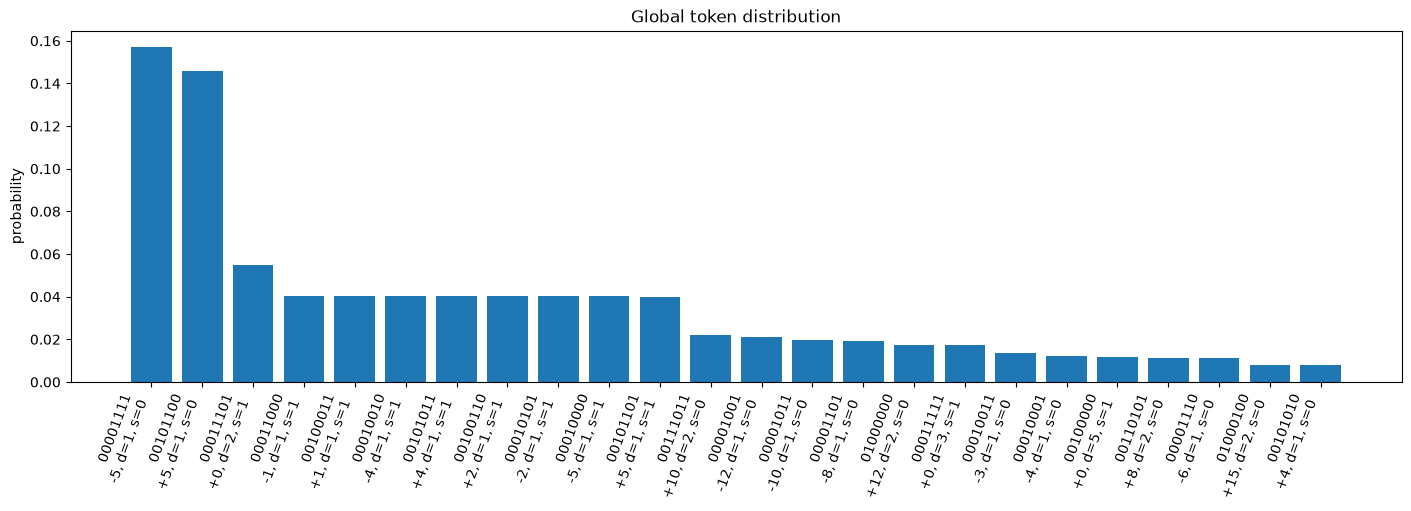

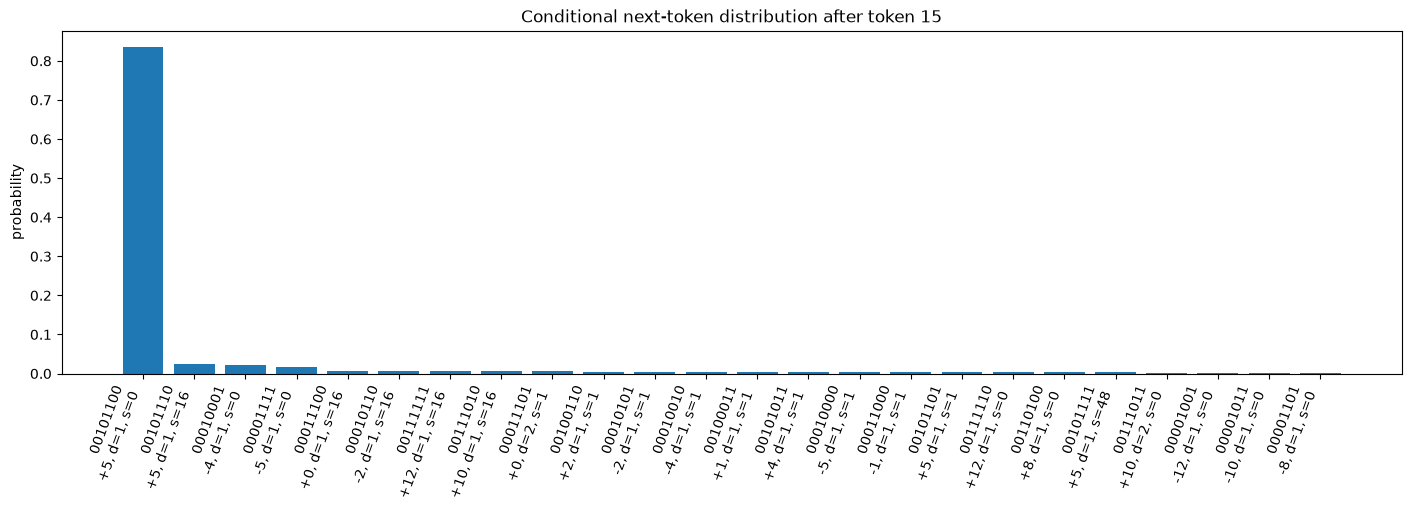

In [6]:
def token_label(token: int) -> str:
    if token >= len(token_to_triplet):
        return f"{token:0{EVENT_TOKEN_BITS}b}*"
    interval, duration, silence = token_to_triplet[token]
    return f"{token:0{EVENT_TOKEN_BITS}b}\n{interval:+d}, d={duration}, s={silence}"


def save_figure(fig, filename: str) -> Path:
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved {path}")
    return path


def plot_token_distribution(probs: np.ndarray, title: str, top_n: int = 24):
    top = np.argsort(probs)[::-1][:top_n]
    labels = [token_label(int(token)) for token in top]
    fig, ax = plt.subplots(figsize=(14, 5), layout="constrained")
    ax.bar(range(len(top)), probs[top])
    ax.set_xticks(range(len(top)), labels, rotation=70, ha="right")
    ax.set_ylabel("probability")
    ax.set_title(title)
    return fig, ax


global_fig, _ = plot_token_distribution(global_probs, "Global token distribution")
save_figure(global_fig, "markov_global_token_distribution.png")

example_current_token = eligible_current_tokens[0] if eligible_current_tokens else int(np.argmax(global_probs))
example_fig, _ = plot_token_distribution(
    conditional_probs.get(example_current_token, global_probs),
    f"Conditional next-token distribution after token {example_current_token}",
)
save_figure(example_fig, "markov_example_conditional_distribution.png")


## 6. Build Qiskit circuits

The global circuit samples `P(token)`. Each conditional circuit samples `P(next_token | current_token)` for one common current token. Rare states fall back to the global circuit.

The entropy shown here is the bipartite von Neumann entropy of the prepared token-index state across a split of the token bits. Because this notebook uses token IDs, this is a circuit-state diagnostic, not an interval-vs-duration-vs-silence entropy.


Built 1 global circuit and 41 conditional circuits
Global token-bit entropy: 1.363 bits / max 4.0, Schmidt rank 5
Example conditional token-bit entropy: 0.594 bits / max 4.0, Schmidt rank 5


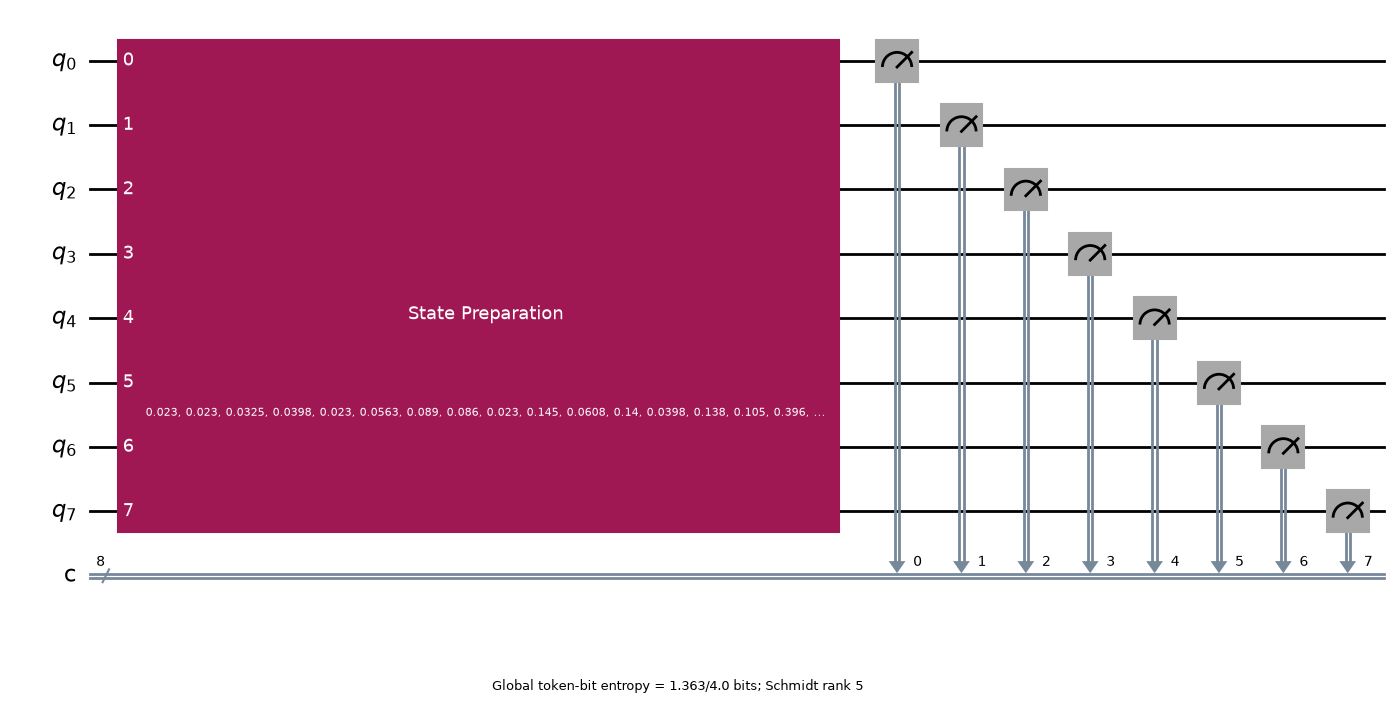

Saved outputs_markov/markov_global_circuit.png


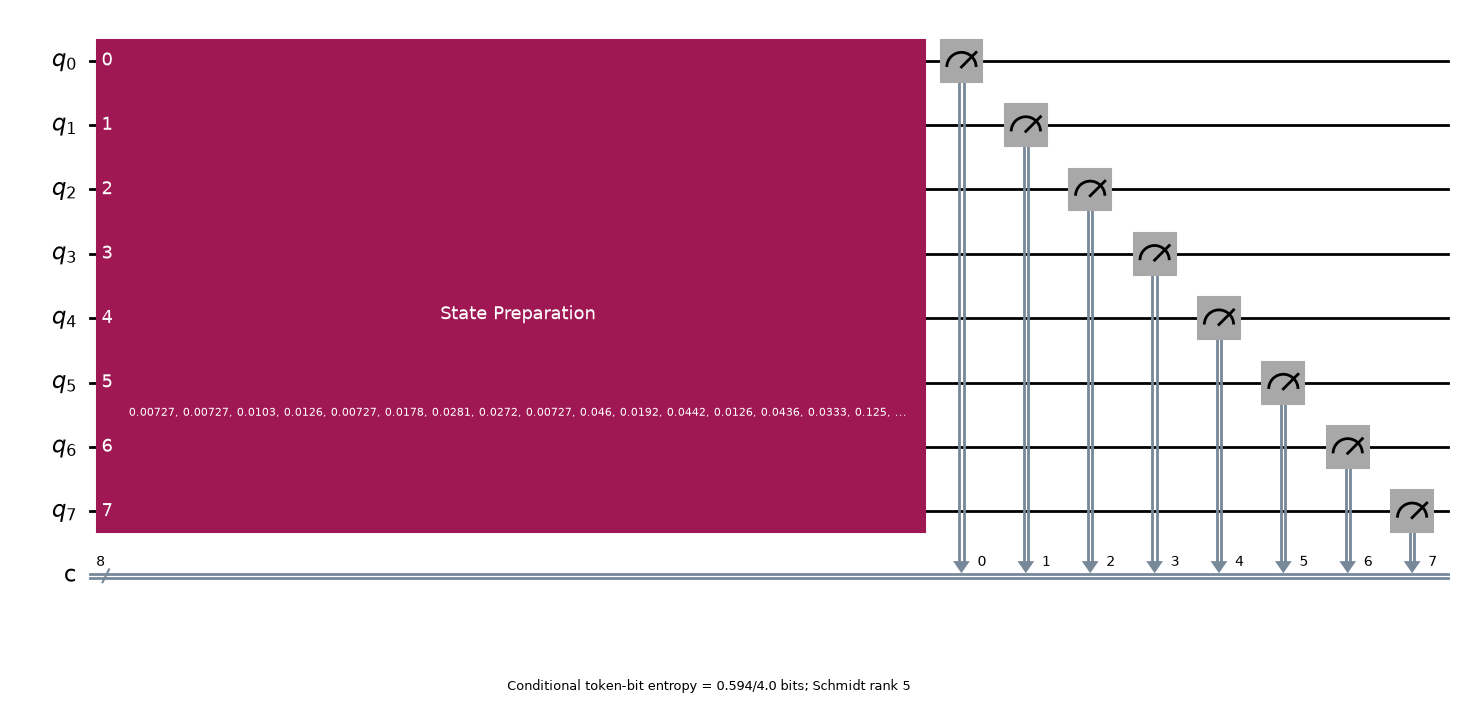

Saved outputs_markov/markov_example_conditional_circuit.png
Quantum Markov token sampler summary
token qubits: 8
used tokens: 80 / 256
conditional circuits: 41
global entropy: 1.363/4.0 bits, Schmidt rank 5
global basis ops: {'u3': 254, 'cx': 247, 'measure': 8}, depth 496
example current token: 15
example conditional entropy: 0.594/4.0 bits
example basis ops: {'u3': 254, 'cx': 247, 'measure': 8}, depth 496
Saved outputs_markov/markov_gate_entropy_summary.txt


In [7]:
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation
from qiskit_aer import AerSimulator


def probs_to_amplitudes(probs: np.ndarray) -> np.ndarray:
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()
    amps = np.sqrt(probs)
    assert np.isclose(np.linalg.norm(amps), 1.0)
    return amps


def token_bit_entropy_bits(amplitudes: np.ndarray, left_bits: int | None = None, tol: float = 1e-12) -> tuple[float, int, float]:
    if left_bits is None:
        left_bits = EVENT_TOKEN_BITS // 2
    right_bits = EVENT_TOKEN_BITS - left_bits
    matrix = amplitudes.reshape((2 ** right_bits, 2 ** left_bits))
    schmidt = np.linalg.svd(matrix, compute_uv=False)
    weights = schmidt ** 2
    weights = weights[weights > tol]
    entropy = -float(np.sum(weights * np.log2(weights))) if len(weights) else 0.0
    return entropy, int(len(weights)), float(min(left_bits, right_bits))


def build_token_sampler(probs: np.ndarray, name: str) -> tuple[QuantumCircuit, np.ndarray, tuple[float, int, float]]:
    amplitudes = probs_to_amplitudes(probs)
    circuit = QuantumCircuit(EVENT_TOKEN_BITS, EVENT_TOKEN_BITS, name=name)
    circuit.append(StatePreparation(amplitudes), range(EVENT_TOKEN_BITS))
    circuit.measure(range(EVENT_TOKEN_BITS), range(EVENT_TOKEN_BITS))
    entropy = token_bit_entropy_bits(amplitudes)
    return circuit, amplitudes, entropy


global_circuit, global_amplitudes, global_entropy = build_token_sampler(global_probs, "global_token_sampler")
conditional_circuits = {}
conditional_entropies = {}
for token, probs in conditional_probs.items():
    circuit, _, entropy = build_token_sampler(probs, f"next_after_{token}")
    conditional_circuits[token] = circuit
    conditional_entropies[token] = entropy

print(f"Built 1 global circuit and {len(conditional_circuits)} conditional circuits")
print(f"Global token-bit entropy: {global_entropy[0]:.3f} bits / max {global_entropy[2]:.1f}, Schmidt rank {global_entropy[1]}")
if example_current_token in conditional_entropies:
    e = conditional_entropies[example_current_token]
    print(f"Example conditional token-bit entropy: {e[0]:.3f} bits / max {e[2]:.1f}, Schmidt rank {e[1]}")

if DRAW_CIRCUIT_IMAGES:
    global_fig = global_circuit.draw(output="mpl", fold=80)
    global_fig.text(
        0.5,
        0.01,
        f"Global token-bit entropy = {global_entropy[0]:.3f}/{global_entropy[2]:.1f} bits; Schmidt rank {global_entropy[1]}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
    global_fig.savefig(OUTPUT_DIR / "markov_global_circuit.png", dpi=160, bbox_inches="tight")
    display(global_fig)
    print(f"Saved {OUTPUT_DIR / 'markov_global_circuit.png'}")

    example_circuit = conditional_circuits.get(example_current_token, global_circuit)
    example_entropy = conditional_entropies.get(example_current_token, global_entropy)
    example_circuit_fig = example_circuit.draw(output="mpl", fold=80)
    example_circuit_fig.text(
        0.5,
        0.01,
        f"Conditional token-bit entropy = {example_entropy[0]:.3f}/{example_entropy[2]:.1f} bits; Schmidt rank {example_entropy[1]}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
    example_circuit_fig.savefig(OUTPUT_DIR / "markov_example_conditional_circuit.png", dpi=160, bbox_inches="tight")
    display(example_circuit_fig)
    print(f"Saved {OUTPUT_DIR / 'markov_example_conditional_circuit.png'}")

basis_global = transpile(global_circuit, basis_gates=["u3", "cx"], optimization_level=1, seed_transpiler=SEED)
basis_example = transpile(conditional_circuits.get(example_current_token, global_circuit), basis_gates=["u3", "cx"], optimization_level=1, seed_transpiler=SEED)
summary_lines = [
    "Quantum Markov token sampler summary",
    f"token qubits: {EVENT_TOKEN_BITS}",
    f"used tokens: {len(token_to_triplet)} / {MAX_EVENT_TOKENS}",
    f"conditional circuits: {len(conditional_circuits)}",
    f"global entropy: {global_entropy[0]:.3f}/{global_entropy[2]:.1f} bits, Schmidt rank {global_entropy[1]}",
    f"global basis ops: {dict(basis_global.count_ops())}, depth {basis_global.depth()}",
    f"example current token: {example_current_token}",
    f"example conditional entropy: {conditional_entropies.get(example_current_token, global_entropy)[0]:.3f}/{conditional_entropies.get(example_current_token, global_entropy)[2]:.1f} bits",
    f"example basis ops: {dict(basis_example.count_ops())}, depth {basis_example.depth()}",
]
summary_path = OUTPUT_DIR / "markov_gate_entropy_summary.txt"
summary_path.write_text("\n".join(summary_lines) + "\n")
print("\n".join(summary_lines))
print(f"Saved {summary_path}")


## 7. Quantum Markov generation

The current token is classical state. At each step, we choose the conditional circuit for that token if it exists; otherwise we use the global circuit. Measuring the circuit gives the next token, which becomes the current token for the next step.


In [8]:
simulator = AerSimulator(seed_simulator=SEED)
transpiled_global_circuit = transpile(global_circuit, simulator, seed_transpiler=SEED)
transpiled_conditional_circuits = {
    token: transpile(circuit, simulator, seed_transpiler=SEED)
    for token, circuit in conditional_circuits.items()
}


def measure_next_token(current_token: int, step: int) -> tuple[int, str]:
    use_global_mix = rng.random() < GLOBAL_MIX_PROBABILITY
    has_conditional = current_token in transpiled_conditional_circuits
    if has_conditional and not use_global_mix:
        circuit = transpiled_conditional_circuits[current_token]
        source = "conditional"
    else:
        circuit = transpiled_global_circuit
        source = "global_mix" if has_conditional else "global_fallback"

    # Repeated one-shot Aer jobs with the same fixed seed can replay the same first sample.
    # Vary the simulator seed by step to keep generation reproducible but genuinely stochastic.
    result = simulator.run(circuit, shots=1, seed_simulator=SEED + step + 1).result()
    bitstring = next(iter(result.get_counts()))
    sampled_token = int(bitstring.replace(" ", ""), 2)
    if sampled_token >= len(token_to_triplet):
        sampled_token = int(rng.choice(np.arange(MAX_EVENT_TOKENS), p=global_probs))
        source = source + "+repair"
    return sampled_token, source


def generate_quantum_markov_tokens(n_events: int, start_token: int) -> tuple[list[int], Counter]:
    tokens = []
    circuit_sources = Counter()
    current = start_token
    for step in range(n_events):
        next_token, source = measure_next_token(current, step)
        tokens.append(next_token)
        circuit_sources[source] += 1
        current = next_token
    return tokens, circuit_sources


start_token = encoded_sequences[0][0]
generated_tokens, generation_sources = generate_quantum_markov_tokens(GENERATED_EVENTS, start_token)
print(f"Start token: {start_token} -> {token_to_triplet[start_token]}")
print(f"Circuit sources used: {dict(generation_sources)}")
print("First 24 generated tokens/triplets:")
for token in generated_tokens[:24]:
    print(f"token={token:3d} -> {token_to_triplet[token]}")


Start token: 29 -> (0, 2, 1)
Circuit sources used: {'conditional': 235, 'global_mix': 15, 'global_fallback': 6}
First 24 generated tokens/triplets:
token= 61 -> (11, 2, 0)
token= 10 -> (-11, 1, 0)
token= 29 -> (0, 2, 1)
token= 59 -> (10, 2, 0)
token= 39 -> (2, 2, 0)
token=  9 -> (-12, 1, 0)
token= 29 -> (0, 2, 1)
token= 59 -> (10, 2, 0)
token= 15 -> (-5, 1, 0)
token= 44 -> (5, 1, 0)
token= 15 -> (-5, 1, 0)
token= 44 -> (5, 1, 0)
token= 15 -> (-5, 1, 0)
token= 15 -> (-5, 1, 0)
token= 44 -> (5, 1, 0)
token= 44 -> (5, 1, 0)
token= 15 -> (-5, 1, 0)
token= 44 -> (5, 1, 0)
token= 15 -> (-5, 1, 0)
token= 44 -> (5, 1, 0)
token= 15 -> (-5, 1, 0)
token= 44 -> (5, 1, 0)
token= 15 -> (-5, 1, 0)
token= 44 -> (5, 1, 0)


## 8. Reconstruct and export audio

Each generated token decodes to `(interval, duration, silence)`. The silence is inserted before the note in both the MIDI and square-wave WAV output.


In [9]:
def reflect_pitch_into_range(pitch: int, low: int = OUTPUT_LOW_PITCH, high: int = OUTPUT_HIGH_PITCH) -> int:
    while pitch < low or pitch > high:
        if pitch < low:
            pitch = low + (low - pitch)
        if pitch > high:
            pitch = high - (pitch - high)
    return int(pitch)


def tokens_to_melody(tokens: list[int], start_pitch: int) -> tuple[list[int], list[int], list[int]]:
    pitch = start_pitch
    pitches = []
    durations = []
    silences = []
    for token in tokens:
        interval, duration_steps, silence_steps = token_to_triplet[token]
        pitch = reflect_pitch_into_range(pitch + interval)
        pitches.append(pitch)
        durations.append(duration_steps_to_ticks(duration_steps))
        silences.append(silence_steps_to_ticks(silence_steps))
    return pitches, durations, silences


def write_vlq(value: int) -> bytes:
    buffer = [value & 0x7F]
    value >>= 7
    while value:
        buffer.append((value & 0x7F) | 0x80)
        value >>= 7
    return bytes(reversed(buffer))


def write_generated_midi(path: Path, pitches: list[int], durations: list[int], silences: list[int], velocity: int = 96, program: int = 80):
    track = bytearray()
    track += write_vlq(0) + bytes([0xFF, 0x51, 0x03]) + OUTPUT_TEMPO_US_PER_BEAT.to_bytes(3, "big")
    track += write_vlq(0) + bytes([0xC0, program])
    for pitch, duration, silence in zip(pitches, durations, silences):
        pitch = int(np.clip(pitch, 0, 127))
        track += write_vlq(max(0, int(silence))) + bytes([0x90, pitch, velocity])
        track += write_vlq(max(1, int(duration))) + bytes([0x80, pitch, 0])
    track += write_vlq(0) + bytes([0xFF, 0x2F, 0x00])

    header = b"MThd" + (6).to_bytes(4, "big") + (0).to_bytes(2, "big") + (1).to_bytes(2, "big") + OUTPUT_TICKS_PER_BEAT.to_bytes(2, "big")
    chunk = b"MTrk" + len(track).to_bytes(4, "big") + bytes(track)
    path.write_bytes(header + chunk)


def midi_pitch_to_frequency(pitch: int) -> float:
    return 440.0 * (2.0 ** ((pitch - 69) / 12.0))


def synth_square_wave(pitches: list[int], durations: list[int], silences: list[int], sample_rate: int = 22_050, amplitude: float = 0.25) -> np.ndarray:
    chunks = []
    seconds_per_tick = OUTPUT_TEMPO_US_PER_BEAT / 1_000_000 / OUTPUT_TICKS_PER_BEAT
    for pitch, duration_ticks, silence_ticks in zip(pitches, durations, silences):
        silence_samples = int(round(max(0, silence_ticks) * seconds_per_tick * sample_rate))
        if silence_samples:
            chunks.append(np.zeros(silence_samples))

        duration_seconds = max(0.02, duration_ticks * seconds_per_tick)
        n = max(1, int(round(duration_seconds * sample_rate)))
        t = np.arange(n) / sample_rate
        wave_chunk = amplitude * np.sign(np.sin(2 * np.pi * midi_pitch_to_frequency(pitch) * t))
        fade = min(n // 2, int(0.005 * sample_rate))
        if fade > 1:
            envelope = np.ones(n)
            envelope[:fade] = np.linspace(0, 1, fade)
            envelope[-fade:] = np.linspace(1, 0, fade)
            wave_chunk *= envelope
        chunks.append(wave_chunk)
    return np.concatenate(chunks) if chunks else np.array([], dtype=float)


def write_wav(path: Path, audio: np.ndarray, sample_rate: int = 22_050):
    audio_i16 = np.int16(np.clip(audio, -1, 1) * 32767)
    with wave.open(str(path), "wb") as f:
        f.setnchannels(1)
        f.setsampwidth(2)
        f.setframerate(sample_rate)
        f.writeframes(audio_i16.tobytes())


generated_pitches, generated_durations, generated_silences = tokens_to_melody(generated_tokens, START_PITCH)

midi_path = OUTPUT_DIR / "generated_quantum_markov.mid"
wav_path = OUTPUT_DIR / "generated_quantum_markov.wav"
write_generated_midi(midi_path, generated_pitches, generated_durations, generated_silences)
audio = synth_square_wave(generated_pitches, generated_durations, generated_silences)
write_wav(wav_path, audio)

print(f"Wrote {midi_path}")
print(f"Wrote {wav_path}")
print("First 24 generated pitch/duration/silence ticks:")
print(list(zip(generated_pitches, generated_durations, generated_silences))[:24])

try:
    from IPython.display import Audio, display
    display(Audio(audio, rate=22_050))
except Exception as exc:
    print("Inline audio display is unavailable in this environment.")
    print(type(exc).__name__, exc)


Wrote outputs_markov/generated_quantum_markov.mid
Wrote outputs_markov/generated_quantum_markov.wav
First 24 generated pitch/duration/silence ticks:
[(51, 96, 0), (50, 48, 0), (50, 96, 48), (60, 96, 0), (62, 96, 0), (50, 48, 0), (50, 96, 48), (60, 96, 0), (55, 48, 0), (60, 48, 0), (55, 48, 0), (60, 48, 0), (55, 48, 0), (50, 48, 0), (55, 48, 0), (60, 48, 0), (55, 48, 0), (60, 48, 0), (55, 48, 0), (60, 48, 0), (55, 48, 0), (60, 48, 0), (55, 48, 0), (60, 48, 0)]


## What to refine next

- Change `EVENT_TOKEN_BITS` to control how many complete triplets can survive tokenization.
- Change `MAX_CONDITIONAL_CIRCUITS`, `MIN_TRANSITION_COUNT`, and `TRANSITION_SMOOTHING_ALPHA` to tune how much generation depends on local transition context versus the global fallback.
- Add noisy Markov generation after the musical behavior is acceptable in the ideal simulator.
- Later, replace exact `StatePreparation` with a trainable variational circuit for the global distribution or the conditional distributions.
